In [1]:
from ESF_gurobipy_NJC2025_Ex3_1 import parallel_calculate_sm_esf_processes, generate_design_vectors_sobol
from ppopt.mplp_program import MPLP_Program
from ppopt.mpmodel import MPModeler
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm
import numpy as np
from collections import defaultdict
from typing import List
from scipy.optimize import linprog
import warnings
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import gurobipy as gp
from gurobipy import GRB
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
import math
from gurobipy import nlfunc

##############################################################################################################
# FEASIBILITY FUNCTION AND UNCERTAINTY BOUNDS
##############################################################################################################

In [2]:
def mpformulate_theta_bounds(flex_sol, num_theta: int, theta_bounds: list, num_design: int = 0, design_bounds: list = None, psi_idx: int = 0, theta_m: int = 0):
    A0, b0, F0 = np.empty((len(flex_sol), num_theta)), np.empty(
        (len(flex_sol), 1)), np.empty((len(flex_sol), num_design))
    num_cr = len(flex_sol.critical_regions)
    for i, region in enumerate(flex_sol.critical_regions):
        A0[i] = region.A[psi_idx, :num_theta]
        b0[i] = -region.b[psi_idx]
        F0[i] = -region.A[psi_idx, num_theta:num_theta+num_design]
    # print(f'num_cr:{num_cr}')
    # print(f'num_theta:{num_theta}')
    # print(f'num_design:{num_design}')
    # print(f"A0: {A0}")
    # print(f"b0: {b0}")
    # print(f"F0: {F0}")

    c = np.hstack([np.array([-1, 1]).reshape(1, -1),
                  np.zeros((1, 2 * (num_theta - 1 - theta_m)))]).reshape(-1, 1)
    # print(f'c:{c}')
    # print(f'c.shape: {c.shape}')

    row1_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (A0[:, [i]], np.zeros((num_cr, 1)))])
    row2_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (np.zeros((num_cr, 1)), A0[:, [i]])])
    bound_row = np.hstack([np.array([-1, 1]).reshape(1, -1),
                          np.zeros((1, 2 * (num_theta - 1 - theta_m)))])
    A = np.vstack([row1_block, row2_block, bound_row, -
                  np.eye(2*(num_theta-theta_m)), np.eye(2*(num_theta-theta_m))])
    # print(f'A: {A}')
    # print(f'A.shape: {A.shape}')

    x_lb = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][0]] * 2])
    x_ub = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][1]] * 2])
    b = np.vstack([b0, b0, np.zeros((1, 1)), -
                  x_lb.reshape(-1, 1), x_ub.reshape(-1, 1)])
    # print(f'b: {b}')
    # print(f'b.shape: {b.shape}')

    if F0.size == 0 and theta_m == 0:
        # print('here')
        return A, b, c, np.array([]), np.array([]), np.array([]), np.array([])

    F = np.vstack([F0, F0, np.zeros((1, num_design)), np.zeros(
        (4*(num_theta-theta_m), num_design))]) if num_design > 0 else np.vstack([F0, F0])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')
    if theta_m > 0:
        F_lltheta = np.hstack([A0[:, [i]] for i in range(theta_m)])
        # print(f'F_lltheta: {F_lltheta}')
        # print(f'F_lltheta.shape: {F_lltheta.shape}')
        F = np.hstack([np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))]), F]
                      ) if F.size > 0 else np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')

    H = np.zeros((2*(num_theta-theta_m), theta_m+num_design))
    # print(f'H:{H}')
    # print(f'H.shape: {H.shape}')

    A_t = np.vstack([-np.eye(theta_m+num_design), np.eye(theta_m+num_design)])
    # print(f'A_t:{A_t}')
    # print(f'A_t.shape: {A_t.shape}')

    theta_lb = np.array([-theta_bounds[i][0] for i in range(theta_m)] + ([-j[0] for j in design_bounds] if isinstance(design_bounds, list)
                                                                         else [])).reshape(-1, 1)
    theta_ub = np.array([theta_bounds[i][1] for i in range(theta_m)] + ([j[1] for j in design_bounds] if isinstance(design_bounds, list)
                                                                        else [])).reshape(-1, 1)

    b_t = np.vstack([theta_lb, theta_ub])
    # print(f'b_t:{b_t}')
    # print(f'b_t.shape: {b_t.shape}')

    return A, b, c, H, A_t, b_t, F

def get_theta_bounds(flex_sol, numt, tbounds, numd: int = 0, dbounds: list = None, mp_algo: mpqp_algorithm = mpqp_algorithm.combinatorial):
    theta_bound_dict = defaultdict(dict)
    prob_dict = defaultdict(dict)

    for i in range(numt):
        A, b, c, H, A_t, b_t, F = mpformulate_theta_bounds(
            flex_sol=flex_sol, num_theta=numt, num_design=numd, theta_bounds=tbounds, design_bounds=dbounds, theta_m=i)
        # print(f'A.shape:{A.shape}')
        # print(f'b.shape: {b.shape}')
        # print(f'F.shape: {F.shape}')
        if F.size != 0:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("error", category=UserWarning, message="The chebychev ball has either a radius of zero, or the problem is not feasible!")
                    prob = MPLP_Program(A=A, b=b, c=c, H=H, A_t=A_t, b_t=b_t, F=F)

                prob.process_constraints()
                solution = solve_mpqp(problem=prob, algorithm=mp_algo)

                prob_dict[f"t{i}"] = prob
                theta_bound_dict[f"t{i}"] = solution

            except UserWarning as w:
                # MPLP infeasible / degenerate
                print(f"[theta {i}] MPLP infeasible / zero Chebyshev ball: {w}")
                prob_dict[f"t{i}"] = None
                theta_bound_dict[f"t{i}"] = None

        else:
            # LP fallback branch via scipy.optimize.linprog
            linres = linprog(c=c, A_ub=A, b_ub=b)

            if not linres.success:
                print(f"[theta {i}] linprog failed: status={linres.status}, "f"message={linres.message}")
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = None
            else:
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = [linres.x[1], linres.x[0]]

        print(f"Finished solving for theta{i+1}")

    probs = [p for _, p in prob_dict.items()]
    sols = [sol for _, sol in theta_bound_dict.items()]
    return probs, sols


def get_bounds_regions(sols: List, min_idx: int = 1, max_idx: int = 0):
    t_bounds_list = []
    t_regions_list = []

    for theta_sol in sols:
        if theta_sol is None:
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        if not getattr(theta_sol, "critical_regions", None):
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        min_max_list = []
        region_list = []

        for cr in theta_sol.critical_regions:
            # Store bounds
            Ab = np.concatenate([cr.A, cr.b], axis=1)[:2]
            min_max_list.append([Ab[min_idx].tolist(), Ab[max_idx].tolist()])

            # Store region constraints
            Ef = np.concatenate([cr.E, -cr.f], axis=1)
            region_array = np.array([row.tolist() for row in Ef], dtype=float)
            region_list.append(region_array)

        # Append per-theta data
        t_bounds_list.append(np.array(min_max_list))
        # <-- each region is a 2D array
        t_regions_list.append(np.array(region_list, dtype=object))

    return t_bounds_list, t_regions_list

##############################################################################################################
# PREPARE STATE DATA
##############################################################################################################

In [3]:
def _prepare_state_data(state, tbounds, dbounds, *, solve_algo, theta_algo, log=False):
    """
    Build and solve the flexibility problem for one state, then return only valid theta-related data.

    Returns
    -------
    dict with keys:
        state
        flex_sol
        sol_list
        t_bounds_list
        t_regions_list
        filtered_solutions
        filtered_theta_bounds
        filtered_theta_regions
    or None if no valid theta regions exist.
    """
    state_model = create_flexibility_model(y_list=state, tbounds=tbounds, dbounds=dbounds)
    state_prob = state_model.formulate_problem()
    state_prob.process_constraints()

    flex_sol = solve_mpqp(problem=state_prob, algorithm=solve_algo)
    
    numt = len(tbounds)
    numd = len(dbounds)

    if log:
        print(
            f"Number of critical regions in for flexibility function for state {state}: {len(flex_sol.critical_regions)}")

    _, sol_list = get_theta_bounds(flex_sol=flex_sol, numt=numt, numd=numd, tbounds=tbounds, dbounds=dbounds,
                                   mp_algo=theta_algo)

    t_bounds_list, t_regions_list = get_bounds_regions(sols=sol_list)

    filtered_solutions = []
    filtered_theta_bounds = []
    filtered_theta_regions = []

    for k, (sol, tb, tr) in enumerate(zip(sol_list, t_bounds_list, t_regions_list)):
        if sol is None or tb is None or tr is None:
            # mark as empty stage but preserve position
            filtered_solutions.append(None)
            filtered_theta_bounds.append(None)
            filtered_theta_regions.append(None)
        else:
            filtered_solutions.append(sol)
            filtered_theta_bounds.append(tb)
            filtered_theta_regions.append(tr)

    return {
        "state": state,
        "flex_sol": flex_sol,
        "sol_list": sol_list,
        "theta_bounds_list": t_bounds_list,
        "theta_regions_list": t_regions_list,
        "filtered_solutions": filtered_solutions,
        "filtered_theta_bounds": filtered_theta_bounds,
        "filtered_theta_regions": filtered_theta_regions,
    }

##############################################################################################################
# CASE STUDY
##############################################################################################################

In [4]:
demand_theta_nominal = {
    'B': 7,
    'C': 4,
}

demand_theta_stddev = {
    'B': (0.3)**(0.5),
    'C': (0.3)**(0.5),
}

t_bounds = [
    (demand_theta_nominal['B'] - 4*demand_theta_stddev['B'], demand_theta_nominal['B'] + 4*demand_theta_stddev['B']),
    (demand_theta_nominal['C'] - 4*demand_theta_stddev['C'], demand_theta_nominal['C'] + 4*demand_theta_stddev['C']),
]

d_bounds = [(15, 25), (14, 26)]
nt = len(t_bounds)
nd = len(d_bounds)
y_dict = {
    (1,1): 0.64,
    (1,0.5): 0.08,
    (1,0): 0.08,
    (0.5,1): 0.12,
    (0.5,0.5): 0.015,
    (0.5,0): 0.015,
    (0,1): 0.04,
    (0,0.5): 0.005,
    (0,0): 0.005,
}

case_study = 'NJC2025_Ex3_1'
quad_method = 'smolyak'
smolyak_level = 16

feasibility_algo = mpqp_algorithm.combinatorial_parallel
theta_bounds_algo = mpqp_algorithm.combinatorial_parallel

feas_algo_name = 'gp' if feasibility_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
tb_algo_name = 'gp' if theta_bounds_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')

def create_flexibility_model(tbounds:list, dbounds:list, y_list: tuple = None):
    a_rxn = 0.99218
    
    if y_list is None:
        y_list = [1]*len(dbounds)
    m = MPModeler()
    
    u = m.add_var(name='u')
    ma = m.add_var(name='ma')
    
    t_demand_b = m.add_param('t_demand_b')
    t_demand_c = m.add_param('t_demand_c')
    d_pipe = m.add_param('d_pipe')
    d_volume = m.add_param('d_volume')
    
    m.add_constr(-ma + 0.2 * a_rxn * y_list[1] * d_volume <= u)
    m.add_constr(ma - a_rxn * y_list[1] * d_volume <= u)
    m.add_constr(ma - y_list[0] * d_pipe <= u)
    m.add_constr(-30 -ma + 0.8 * a_rxn * y_list[1] * d_volume <= u)
    m.add_constr(-0.6 * ma + t_demand_b <= u)
    m.add_constr(-0.4 * ma + t_demand_c <= u)
    
    m.add_constr(t_bounds[0][0] <= t_demand_b)
    m.add_constr(t_demand_b <= tbounds[0][1])
    m.add_constr(tbounds[1][0] <= t_demand_c)
    m.add_constr(t_demand_c <= tbounds[1][1])

    m.add_constr(dbounds[0][0] <= d_pipe)
    m.add_constr(d_pipe <= dbounds[0][1])
    m.add_constr(dbounds[1][0] <= d_volume)
    m.add_constr(d_volume <= dbounds[1][1])
    
    m.set_objective(u)
    
    return m

def joint_pdf(theta: list, eps:float = 1e-8):
    theta_b, theta_c = theta
    b_nom, c_nom = demand_theta_nominal['B'], demand_theta_nominal['C']
    b_std, c_std = demand_theta_stddev['B'], demand_theta_stddev['C']
    
    contrib_b = (1/np.sqrt(2*np.pi)) * (1/b_std) * np.exp(-(theta_b - b_nom)**2/(2 * b_std**2))
    
    contrib_c = (1/np.sqrt(2*np.pi)) * (1/c_std) * np.exp(-(theta_c - c_nom)**2/(2 * c_std**2))
    
    return contrib_b * contrib_c

def pdf_builder(theta, n, eps=1e-8):
    theta_b = theta[(0, n)]
    theta_c = theta[(1, n)]
    b_nom, c_nom = demand_theta_nominal['B'], demand_theta_nominal['C']
    b_std, c_std = demand_theta_stddev['B'], demand_theta_stddev['C']
    
    contrib_b = (1/np.sqrt(2*math.pi)) * (1/b_std) * nlfunc.exp(-((theta_b - b_nom) * (theta_b - b_nom))/(2 * b_std * b_std))
    
    contrib_c = (1/np.sqrt(2*math.pi)) * (1/c_std) * nlfunc.exp(-((theta_c - c_nom) * (theta_c - c_nom))/(2 * c_std * c_std))
    
    return contrib_b * contrib_c

cost_coeff_list = [5,10]
def cost_function(d):
    coeffs = np.array(cost_coeff_list)
    return float(np.dot(coeffs, d))

In [5]:
prepared_data_by_state = {
    state: _prepare_state_data(
        state,
        tbounds=t_bounds,
        dbounds=d_bounds,
        solve_algo=feasibility_algo,
        theta_algo=theta_bounds_algo,
    )
    for state in y_dict
}

load_prepared_data_by_state = prepared_data_by_state

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-12
Spawned threads across 24
Time at depth test 1, 0.1069033145904541
Number of active sets to be considered is 5
Time to run all tasks in parallel 0.23824620246887207
Time to process all depth outputs 0.0
Time at depth test 2, 0.34514951705932617
Number of active sets to be considered is 10
Time to run all tasks in parallel 0.2106029987335205
Time to process all depth outputs 0.0
Time at depth test 3, 0.5557525157928467
Number of active sets to be considered is 3
Time to run all tasks in parallel 0.1098015308380127
Time to process all depth outputs 0.0
Spawned threads across 24
Time at depth test 1, 0.0
Number of active sets to be considered is 17
Time to run all tasks in parallel 0.1700747013092041
Time to process all depth outputs 0.0
Time at depth test 2, 0.1700747013092041
Number of active sets to be considered is 105
Time to run all tasks in parallel 0.07056450843811035
Time to process all dep

In [6]:
ns=1024*8

In [7]:
ns

8192

In [8]:
dvector_list_sobol = generate_design_vectors_sobol(d_bounds, n_samples=ns)

In [9]:
# results = parallel_calculate_sm_esf_processes(
#     design_vectors=dvector_list_sobol,
#     y_d=y_dict,
#     load_prepared_data_by_s=load_prepared_data_by_state,
#     s_level=smolyak_level,
#     show_progress=True,
#     # cost_func=cost_function,
#     # joint_func=joint_pdf,
# )

Using 24 workers


Evaluating design vectors:   0%|          | 0/8192 [00:00<?, ?it/s]

In [10]:
# with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [11]:
with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'rb') as f:
    load_results = pickle.load(f)

##############################################################################################################
# OPTIMAL SIMULATION RESULTS
##############################################################################################################

In [12]:
esf_target_list = [0.6, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8, 0.825, 0.85]

In [13]:
def select_best_design(results, esf_target):
    """
    Select the best design such that:
    1. esf_sm >= esf_target
    2. minimum overshoot above esf_target
    3. tie-breaker: minimum cost
    """
    feasible = [r for r in results if r["esf_sm"] >= esf_target]

    if not feasible:
        return None

    return min(
        feasible,
        key=lambda r: (r["esf_sm"] - esf_target, r["cost"])
    )


In [14]:
sim_esf_list, sim_cost_list, sim_design_list = list(), list(), list()
for esf in esf_target_list:
    best_result = select_best_design(load_results, esf)
    if best_result is not None:
        sim_esf_list.append(best_result['esf_sm'])
        sim_cost_list.append(best_result['cost'])
        sim_design_list.append(best_result['design_vector'])

In [15]:
sim_design_list

[array([15.24292691, 14.00080341]),
 array([21.23142428, 16.22105379]),
 array([16.7804243 , 23.49263766]),
 array([23.5992989 , 14.76255369]),
 array([24.53912633, 18.24702322]),
 array([24.78231826, 22.35043392]),
 array([24.64117233, 23.7704577 ]),
 array([24.78944981, 24.86594975])]

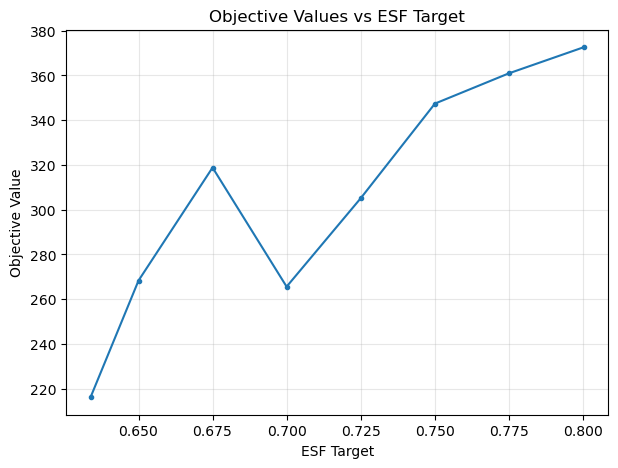

In [16]:
plt.figure(figsize=(7,5))
plt.plot(sim_esf_list, sim_cost_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
# plt.xscale("log")
# plt.yscale("log")   # optional but often useful
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()

##############################################################################################################
# REGRESSION
##############################################################################################################

In [35]:
def build_regression_dataset(results):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"] for r in results])
    return X, y

def fit_polynomial_esf_model_zero_intercept(results, degree=2):
    """
    Polynomial regression with intercept forced to zero:
    esf_sm ≈ sum_j coef_j * feature_j, no constant term.
    """
    X, y = build_regression_dataset(results)

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression(fit_intercept=True)),
    ])

    model.fit(X, y)
    return model

def fit_exponential_esf_model(results, degree=1, tol=1e-6):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"]+tol for r in results])

    if np.any(y <= 0):
        raise ValueError("Need y > 0 for log-transform exponential model.")

    base_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    model = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log,
        inverse_func=np.exp,
    )

    model.fit(X, y)
    return model

In [36]:
def feature_to_expr(name, d_vars):
    """
    Convert a PolynomialFeatures feature name to a Gurobi expression
    in variables d_vars (tupledict or list of decision variables).
    Supports feature names like: 'x0', 'x1^2', 'x0 x1', 'x0^2 x2', etc.
    """
    # Single variable, maybe with power
    if "^" in name and " " not in name:
        base, pow_str = name.split("^")
        idx = int(base[1:])  # 'x0' -> 0
        power = int(pow_str)
        expr = d_vars[idx]
        for _ in range(power - 1):
            expr = expr * d_vars[idx]  # quadratic or higher
        return expr

    # Product of different variables, maybe repeated: 'x0 x1', 'x0^2 x2', etc.
    parts = name.split(" ")
    expr = 1.0
    for p in parts:
        if "^" in p:
            base, pow_str = p.split("^")
            idx = int(base[1:])
            power = int(pow_str)
            term = d_vars[idx]
            for _ in range(power - 1):
                term = term * d_vars[idx]
        else:
            idx = int(p[1:])
            term = d_vars[idx]
        expr = expr * term
    return expr

In [37]:
def plot_actual_vs_predicted_poly(model, X, y, title_prefix="Polynomial regression"):
    # Predictions
    y_pred = model.predict(X)

    # Metrics (optional but useful)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.5, edgecolor="k")
    plt.xlabel("Actual esf_sm")
    plt.ylabel("Predicted esf_sm")

    title = f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}"
    plt.title(title)

    # 45-degree line
    min_v = min(y.min(), y_pred.min())
    max_v = max(y.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [38]:
def plot_regression_diagnostics(
    model,
    X,
    y,
    title_prefix="Regression model",
    figsize=(12, 5),
    point_alpha=0.35,
    point_size=30,
):
    """
    Plot:
      1) Actual vs predicted
      2) Residuals vs predicted

    Works for any fitted model with model.predict(X).
    """
    y = np.asarray(y)
    y_pred = np.asarray(model.predict(X))
    residuals = y - y_pred

    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Left: Actual vs predicted ----
    ax = axes[0]
    ax.scatter(
        y,
        y_pred,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )

    min_v = min(np.min(y), np.min(y_pred))
    max_v = max(np.max(y), np.max(y_pred))
    ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    ax.set_xlabel("Actual esf_sm")
    ax.set_ylabel("Predicted esf_sm")
    ax.set_title(f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}")
    ax.grid(alpha=0.2)

    # Optional: keep same scales visually
    ax.set_xlim(min_v, max_v)
    ax.set_ylim(min_v, max_v)

    # ---- Right: Residuals vs predicted ----
    ax = axes[1]
    ax.scatter(
        y_pred,
        residuals,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )
    ax.axhline(0.0, color="r", linestyle="--", linewidth=2)

    ax.set_xlabel("Predicted esf_sm")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs predicted")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [39]:
reg_degree = nd

In [40]:
poly_model = fit_polynomial_esf_model_zero_intercept(load_results, degree=reg_degree)

poly = poly_model.named_steps["poly"]
lin = poly_model.named_steps["linreg"]

print("Intercept:", lin.intercept_)     # should be 0.0 (or very close numerically)
print("Num features:", len(poly.get_feature_names_out()))

Intercept: 1.6435558734543525
Num features: 5


In [41]:
feature_names = poly.get_feature_names_out()
coefs = lin.coef_  # no intercept

In [42]:
feature_names

array(['x0', 'x1', 'x0^2', 'x0 x1', 'x1^2'], dtype=object)

In [43]:
X, y = build_regression_dataset(load_results)

In [44]:
# exp_model_deg2 = fit_exponential_esf_model(load_results, degree=3)

In [45]:
# plot_regression_diagnostics(
#     exp_model_deg2,
#     X,
#     y,
#     title_prefix="Log-quadratic exp model: esf_sm"
# )

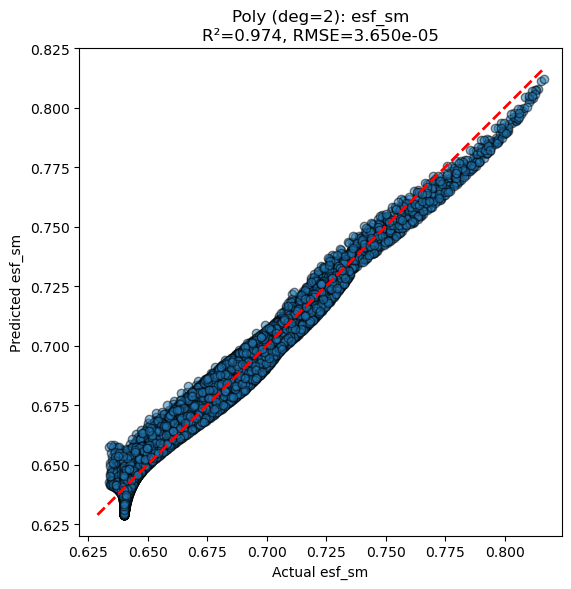

In [46]:
plot_actual_vs_predicted_poly(poly_model, X, y, title_prefix=f"Poly (deg={reg_degree}): esf_sm")

##############################################################################################################
# GUROBI MODEL
##############################################################################################################

In [54]:
def build_base_gurobi_model(dbounds, features, coeffs, intercept=0.0, cost_builder=None, esf_target_init=0.0):
    m = gp.Model("ESF_design")

    d = m.addVars(
        len(d_bounds),
        lb=[b[0] for b in dbounds],
        ub=[b[1] for b in dbounds],
        name="d"
    )

    ESF = m.addVar(lb=0, name="ESF")
    Cost = m.addVar(lb=0, name="Cost")
    
    if cost_builder is None:
        cost_expr = gp.quicksum(d[j] for j in d.keys())
    else:
        cost_expr = gp.quicksum(cost_builder[j]*d[j] for j in d.keys())
        
    m.addConstr(Cost == cost_expr, name='cost_expr')
    
    m.addConstr(ESF >= esf_target_init, name="esf_target_con")
    
    m.setObjective(Cost, GRB.MINIMIZE)
    
    m._esf_expr = intercept
    # m.update()
    for name, coef in zip(features, coeffs):
        if abs(coef) < 1e-12:
            continue
        m._esf_expr += coef * feature_to_expr(name, d)  # d are your Gurobi vars
        # print(esf_expr)
    
    m.addConstr(ESF == m._esf_expr, name="esf_expr")
    
    m.update()
    
    return m

In [55]:
grb_model = build_base_gurobi_model(dbounds=d_bounds, cost_builder=cost_coeff_list, features=feature_names, coeffs=coefs, intercept=lin.intercept_)

In [56]:
esf_expr = grb_model._esf_expr
esf_expr

<gurobi.QuadExpr: 1.6435558734543525 + -0.07445242635918153 d[0] + -0.03979483335989838 d[1] + [ 0.00202560144800354 d[0] ^ 2 + 0.00010066336289846458 d[0] * d[1] + 0.0010902836460166896 d[1] ^ 2 ]>

In [57]:
trade_off_dict = {}
for eps in esf_target_list:
    
    esf_target_con = grb_model.getConstrByName('esf_target_con')
    esf_target_con.RHS = eps
    
    grb_model.optimize()
    
    d_list = list()
    for j in range(len(d_bounds)):
        temp_var = grb_model.getVarByName(f'd[{j}]')
        d_list.append(temp_var.X)
    
    ESF_var = grb_model.getVarByName('ESF')
    
    trade_off_dict[eps] = {
        'design': np.array(d_list),
        'cost': grb_model.ObjVal,
        'ESF': ESF_var.X
    }

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2 rows, 4 columns and 4 nonzeros
Model fingerprint: 0x4fab2b44
Model has 1 quadratic constraint
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  QMatrix range    [1e-04, 2e-03]
  QLMatrix range   [4e-02, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+01, 3e+01]
  RHS range        [6e-01, 6e-01]
  QRHS range       [2e+00, 2e+00]
Presolve removed 2 rows and 1 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 2 rows and 2 columns
Presolve time: 0.00s
Presolved: 5 rows, 6 columns, 15 nonzeros
Presolved model has 3 bilinear constraint(s)
Variable types: 6 continuous, 0 integer (0 binary)
Found heuristic solution: objective 215.0000000

Explored 0 nodes (0 simplex iterations)

AttributeError: Unable to retrieve attribute 'X'

In [58]:
trade_off_dict

{0.6: {'design': array([15., 14.]), 'cost': 215.0, 'ESF': 0.6602370376567974},
 0.65: {'design': array([15., 14.]), 'cost': 215.0, 'ESF': 0.6602370376567974},
 0.675: {'design': array([22.09144153, 14.        ]),
  'cost': 250.45720766828563,
  'ESF': 0.6750534587680493},
 0.7: {'design': array([23.39999763, 14.        ]),
  'cost': 256.99998817262076,
  'ESF': 0.700052619323618},
 0.725: {'design': array([24.44505148, 14.        ]),
  'cost': 262.2252574076558,
  'ESF': 0.7250000000096709},
 0.75: {'design': array([25.        , 21.42148051]),
  'cost': 339.2148050544814,
  'ESF': 0.75},
 0.775: {'design': array([25.        , 23.54876467]),
  'cost': 360.48764667480776,
  'ESF': 0.7750000000053796},
 0.8: {'design': array([25.        , 25.13134193]),
  'cost': 376.3134193154382,
  'ESF': 0.8}}

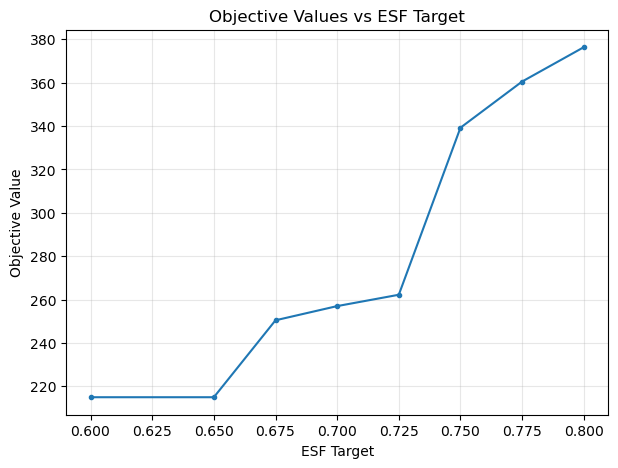

In [59]:
trade_off_esf_list = list(trade_off_dict.keys())
trade_off_cost_list = [v['cost'] for k,v in trade_off_dict.items()]

plt.figure(figsize=(7,5))
plt.plot(trade_off_esf_list, trade_off_cost_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()